## This Notebook gives an example on how to plot the quality control plots for MERFISH cell clustering (Supplementary Figures 2-3 in the manuscript)

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore
import numpy as np
from scipy.stats import ttest_1samp
import seaborn as sns

In [2]:
#### PLOT GENE
# Function to plot gene expression across single cells in X_spatial

def plot_gene_scdata(scdata2,gene='SOX9',nmax=20,sz_min=5,sz_max=30,transpose=1,flipx=1,flipy=1,tag='X_spatial'):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(15, 15), facecolor="white")
    Xcells = scdata2.obsm[tag][:,::transpose]*[flipx,flipy]
    ign = list(scdata2.var.index).index(gene)
    if 'X_raw' not in scdata2.obsm:
        Xnorm = (np.exp(scdata2.X)-1)
        ncts = np.sum(Xnorm,axis=1)[0]
        scdata2.obsm['X_raw']=np.round(Xnorm/ncts*np.array(scdata2.obs['total_counts'])[:,np.newaxis])
    cts = scdata2.obsm['X_raw'][:,ign].copy()
    plt.style.use("default")
    cts[np.isnan(cts)]=0
    #cts[cts>20]=0
    ncts = np.clip(cts/nmax,0,1)
    size = sz_min+ncts*(sz_max-sz_min)
    from matplotlib import cm as cmap
    cols = cmap.coolwarm(ncts)

    good_cells = slice(None)
    good_cells = np.argsort(cts)

    XC = -Xcells[good_cells,::-1]
    fig = plt.figure(facecolor='k')
    plt.title(gene+' - N max '+str(nmax))
    fig.set_facecolor('white')
    plt.scatter(XC[:,0],XC[:,1],c=cols[good_cells],s=size[good_cells])
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.axis("equal")

    return fig

In [3]:
###PLOT CLUSTER NAME
# Function to plot cell-types across single cells in X_spatial

def plot_cluster_name_scdata(scdata,cmap,clusters=['Neuron','Astro'],transpose=1,flipx=1,flipy=1,sbig=30,small=5):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(40, 40), facecolor="white")

    from matplotlib import pylab as plt
    x,y = (scdata.obsm['X_spatial']*[-flipx,-flipy])[:,::-transpose].T
    
    plt.scatter(x, y, c='gray', s=small, marker='.')
    i=0
    for cluster in clusters:
        cluster_ = str(cluster)
        inds = scdata.obs["cluster_names"] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[int(i) % len(cmap)]
        i=i+1
        plt.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_)
    
    plt.grid(False)
    plt.axis("off")
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    return fig

In [4]:
merged_dt=pd.read_csv('/Users/Olatz/BintuLabScripts/SEAAD_PFC/SEAAD_PFC_mean_expression.csv')
merged_dt

,gene,L6b,L6 IT,L6 IT Car3,OPC,Pvalb,L6 CT,L5/6 NP,Sst,L2/3 IT,...,Sncg,Endothelial,Microglia-PVM,Astrocyte,Lamp5,Oligodendrocyte,Pax6,L5 ET,Sst Chodl,VLMC
0,MIR1302-2HG,0.000907,0.000529,0.000633,0.000000,0.001218,0.000300,0.001990,0.000330,0.000274,...,0.000000,0.000000,0.000000,0.000000,0.000475,0.000000,0.000818,0.000622,0.000000,0.000000
1,FAM138A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000011,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,OR4F5,0.000113,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000010,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,AL627309.1,0.008642,0.009105,0.012800,0.001957,0.005966,0.017180,0.009368,0.009600,0.012385,...,0.005943,0.000000,0.014426,0.004775,0.006873,0.003064,0.010288,0.013495,0.013065,0.000000
4,AL627309.3,0.000287,0.000384,0.000544,0.000000,0.000991,0.000991,0.000295,0.000476,0.000627,...,0.000781,0.000000,0.000000,0.000000,0.000479,0.000545,0.000251,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36596,AC141272.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
36597,AC023491.2,0.000133,0.000162,0.000821,0.000000,0.000124,0.000238,0.000000,0.000000,0.000279,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000283,0.000000,0.000000
36598,AC007325.1,0.000166,0.000036,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
36599,AC007325.4,0.024581,0.024196,0.021763,0.030171,0.015437,0.021563,0.022328,0.015687,0.025438,...,0.018709,0.006524,0.004798,0.016879,0.012491,0.009267,0.024821,0.025247,0.015751,0.037303


In [5]:
names_seq= ['gene','L2/3 IT','L4 IT', 'L5 IT','L5 ET', 'L5/6 NP', 'L6 IT', 'L6 IT Car3','L6 CT','L6b',  'Lamp5', 'Lamp5 Lhx6','Pax6',  'Sncg','Vip','Sst','Sst Chodl','Pvalb', 'Chandelier',  'Astrocyte','OPC',  'Oligodendrocyte', 'Endothelial','VLMC','Microglia-PVM' ]
merged_dt = merged_dt[names_seq]

In [6]:
#######################################
#### SUPPLEMENTARY FIGURE 2A: Heatmap Cell-type correlation MERFISH_short (188 genes) vs ABA PFC
#######################################

In [7]:
C4 = sc.read_h5ad('../C4_ref.h5ad')

In [8]:
common_var = np.intersect1d(list(merged_dt.gene),list(C4.var.index))
merged_dt_short=merged_dt[merged_dt.gene.isin(common_var)]

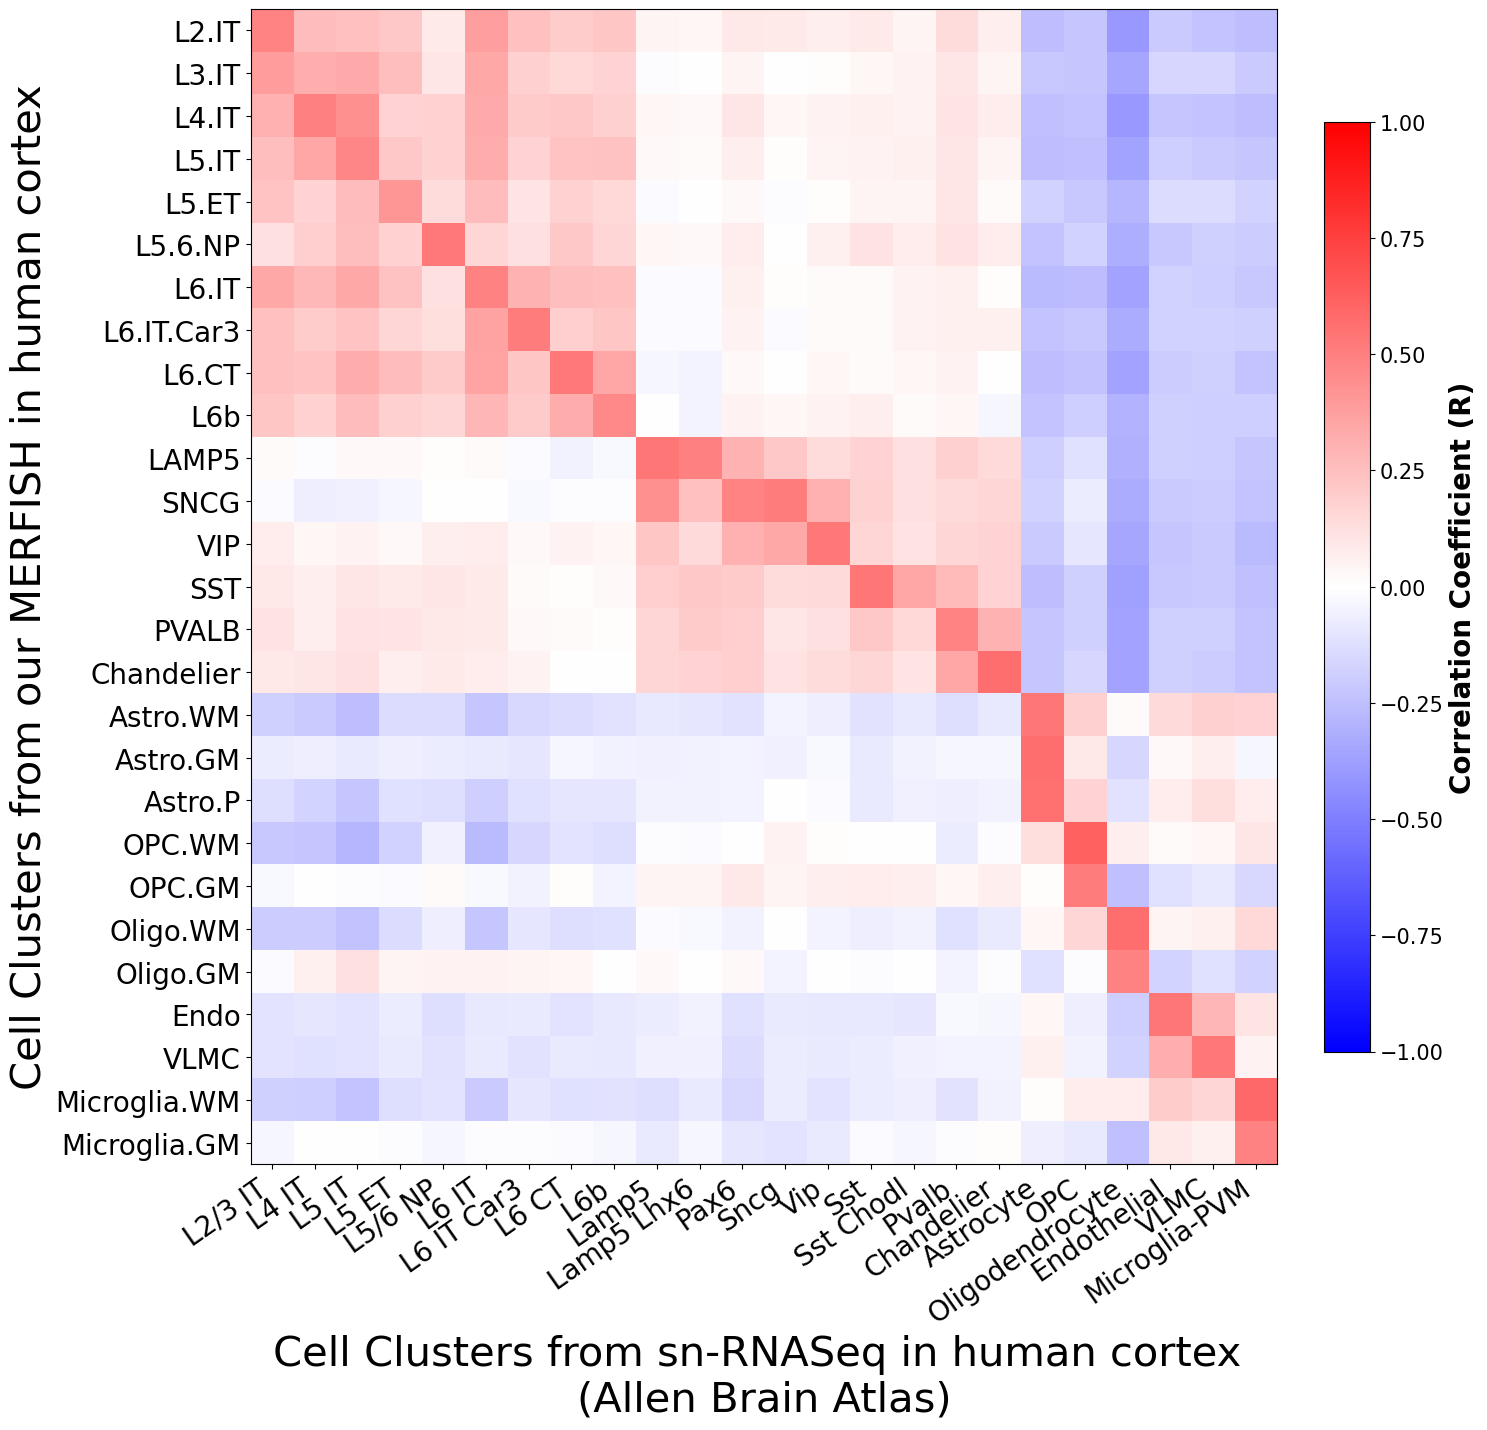

In [9]:
cluster_order = ["L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT','L6.IT.Car3', "L6.CT",'L6b',"LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "Astro.WM", 'Astro.GM','Astro.P', 'OPC.WM','OPC.GM',  'Oligo.WM', 'Oligo.GM','Endo', 'VLMC','Microglia.WM','Microglia.GM']
C4_s = C4[:,merged_dt_short["gene"]]

X_MERFISH_zscored = zscore(C4_s.X,axis=0)
clusters = C4_s.obs['cluster_names']
X_MERFISH_zscored_per_cluster = np.array([np.mean(X_MERFISH_zscored[cl==clusters],axis=0) for cl in cluster_order])

X_seq = np.array(merged_dt_short.iloc[:,1:]).T
X_seq[np.isnan(X_seq)]=0
X_seq_zscored = zscore(X_seq,axis=0)
X_seq_zscored[np.isnan(X_seq_zscored)]=0

Mcor = [[np.corrcoef(clMER,clSEQ)[0,1] for clSEQ in X_seq_zscored] for clMER in X_MERFISH_zscored_per_cluster]
xnames= list(merged_dt_short.keys())[1:]
dic_rename = dict(zip(C4_s.obs['leiden'],C4_s.obs['cluster_names']))

plt.style.use('default')
plt.figure(figsize=(30,15))
im = plt.imshow(Mcor,cmap='bwr', vmin=-1, vmax=1)
cbar = plt.colorbar(im, fraction=0.02, pad=0.02)
cbar.set_label('Correlation Coefficient (R)', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=15)
plt.xticks(np.arange(len(xnames)),xnames,rotation=35,ha='right',size=20);
plt.yticks(np.arange(len(cluster_order)),cluster_order,size=20)
plt.ylabel('Cell Clusters from our MERFISH in human cortex', size=30)
plt.xlabel('Cell Clusters from sn-RNASeq in human cortex \n(Allen Brain Atlas)', size=30);

In [10]:
Mcor = np.array(Mcor)

max_r = Mcor.max(axis=1)
max_idx = Mcor.argmax(axis=1)
max_allen_clusters = [xnames[i] for i in max_idx]

results_df = pd.DataFrame({
    'MERFISH_cluster': cluster_order,
    'Max_correlation': max_r,
    'Best_matching_Allen_cluster': max_allen_clusters
})

mean_corr = np.mean(max_r)
std_corr = np.std(max_r)

t_stat, p_val = ttest_1samp(max_r.flatten(), 0)

print("===== Summary =====")
print(f"Mean correlation (all pairs): {mean_corr:.3f} ± {std_corr:.3f}")
print(f"T-test p-value (r > 0): {p_val:.5f}")
print()
print("===== Per-MERFISH Cluster Max Correlation =====")
print(results_df)


===== Summary =====
Mean correlation (all pairs): 0.514 ± 0.048
T-test p-value (r > 0): 0.00000

===== Per-MERFISH Cluster Max Correlation =====
   MERFISH_cluster  Max_correlation Best_matching_Allen_cluster
0            L2.IT         0.479512                     L2/3 IT
1            L3.IT         0.390598                     L2/3 IT
2            L4.IT         0.493917                       L4 IT
3            L5.IT         0.472185                       L5 IT
4            L5.ET         0.411405                       L5 ET
5          L5.6.NP         0.519876                     L5/6 NP
6            L6.IT         0.489221                       L6 IT
7       L6.IT.Car3         0.509000                  L6 IT Car3
8            L6.CT         0.518663                       L6 CT
9              L6b         0.464417                         L6b
10           LAMP5         0.531592                       Lamp5
11            SNCG         0.514295                        Sncg
12             VIP     

In [11]:
#######################################
#### SUPPLEMENTARY FIGURE 2B: Heatmap of cell-type markers expression across clusters
#######################################

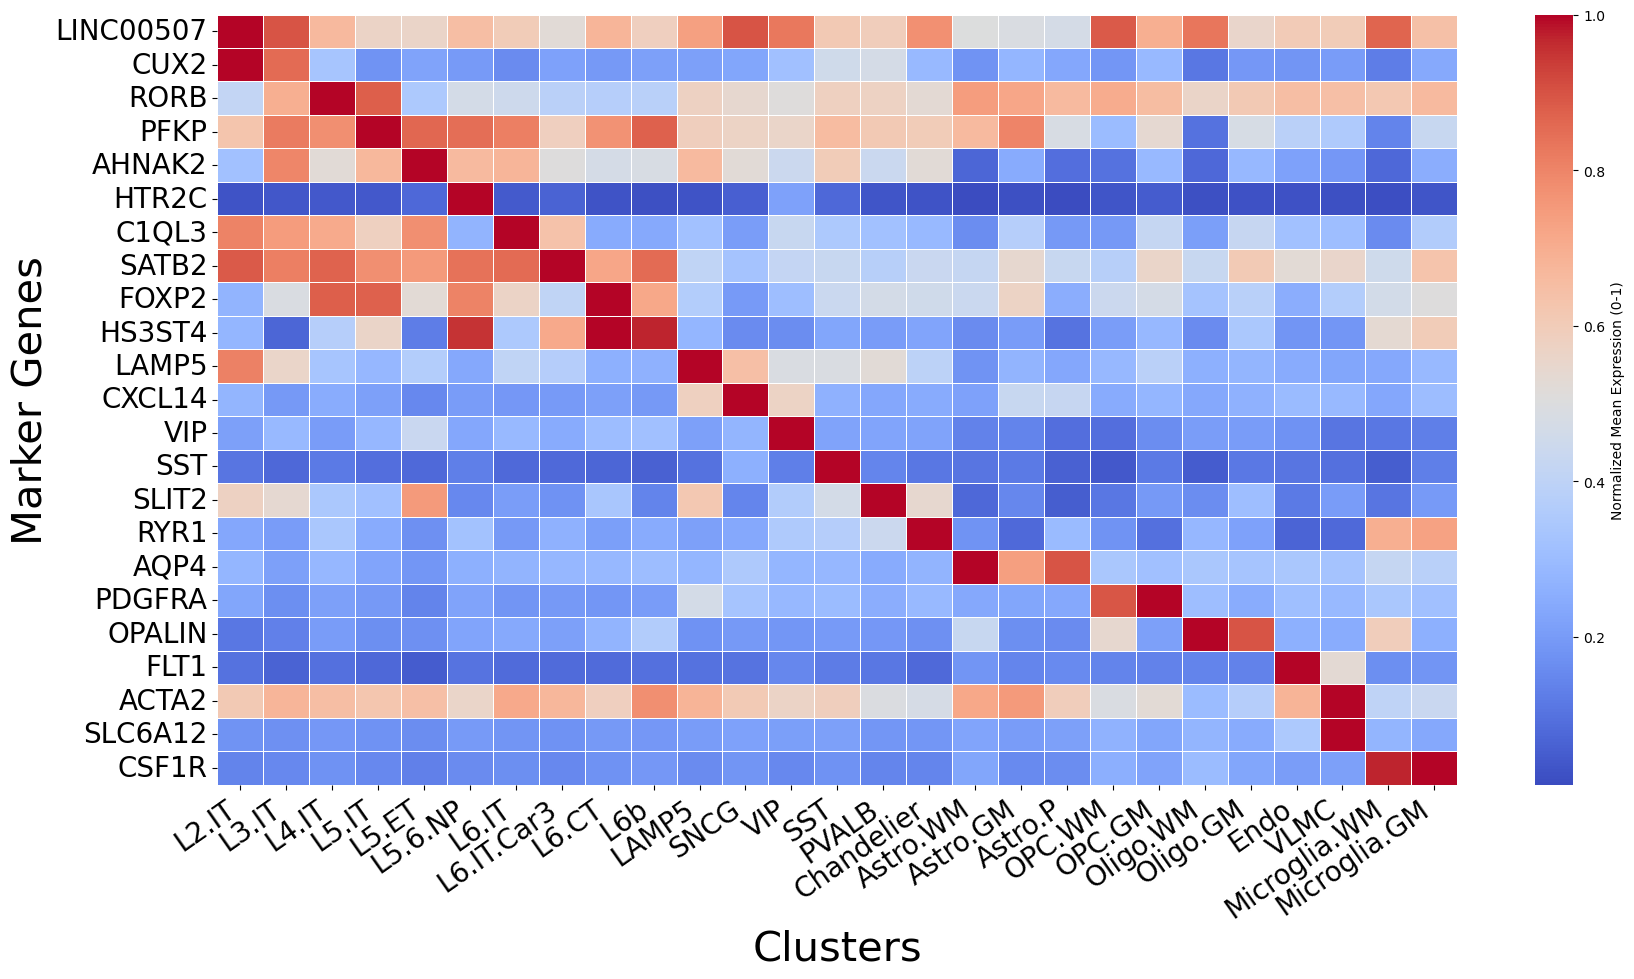

In [12]:
marker_genes = [
    'LINC00507','CUX2', #(L2-3)
    'RORB','PFKP','AHNAK2','HTR2C','C1QL3','SATB2','FOXP2','HS3ST4', #'FEZF2' Layer 56NP, 'HS3ST4'(6CT, 6b, 56NP), 
    'LAMP5','CXCL14','VIP','SST','SLIT2','RYR1',
    'AQP4','PDGFRA','OPALIN','FLT1','ACTA2','SLC6A12','CSF1R'
]

data_matrix = pd.DataFrame(
    C4[:, marker_genes].X.toarray(), 
    index=C4.obs['cluster_names'],
    columns=marker_genes
).groupby('cluster_names').mean().reindex(cluster_order)

data_matrix_normalized = data_matrix.divide(data_matrix.max(axis=0), axis=1)

plt.figure(figsize=(20, 10))
sns.heatmap(
    data_matrix_normalized.T,  # Transposed to match `swap_axes=True`
    cmap='coolwarm',
    cbar_kws={'label': 'Normalized Mean Expression (0-1)'},
    linewidths=0.5, 
    linecolor='white'
)

plt.xticks(rotation=35, fontsize=20, ha='right')
plt.yticks(fontsize=20)
plt.xlabel("Clusters", fontsize=30)
plt.ylabel("Marker Genes", fontsize=30)
plt.savefig('Figures/SF2B.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [13]:
#######################################
#### SUPPLEMENTARY FIGURE 2C: Cell-type marker expression and cell clusters across single cells in X_spatial
#######################################

<Figure size 1500x1500 with 0 Axes>

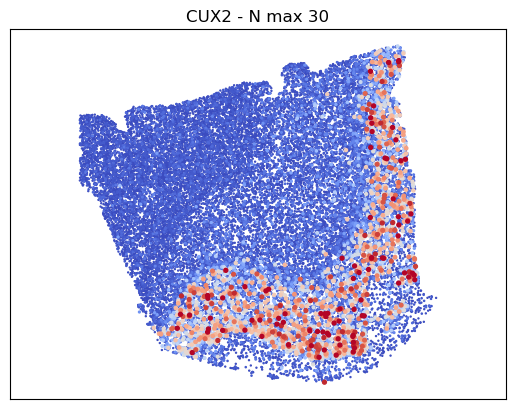

<Figure size 1500x1500 with 0 Axes>

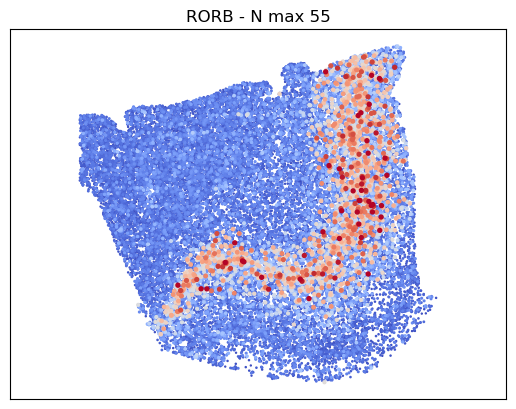

<Figure size 1500x1500 with 0 Axes>

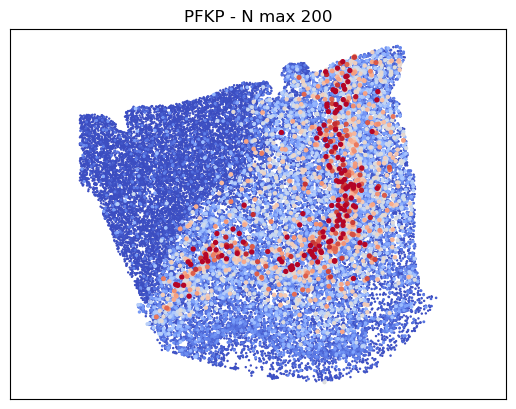

<Figure size 1500x1500 with 0 Axes>

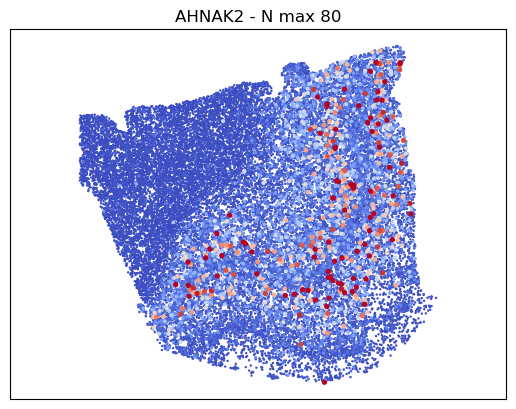

<Figure size 1500x1500 with 0 Axes>

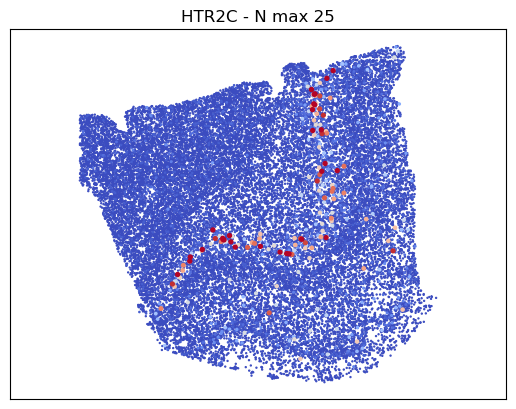

<Figure size 1500x1500 with 0 Axes>

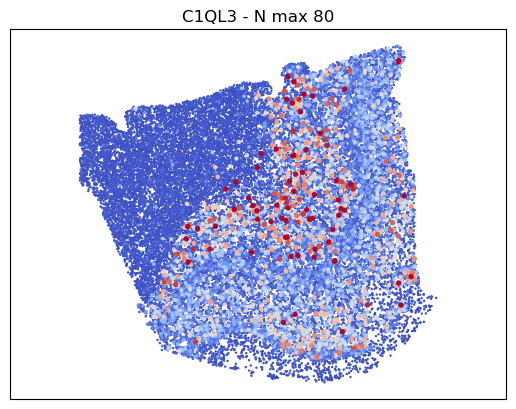

<Figure size 1500x1500 with 0 Axes>

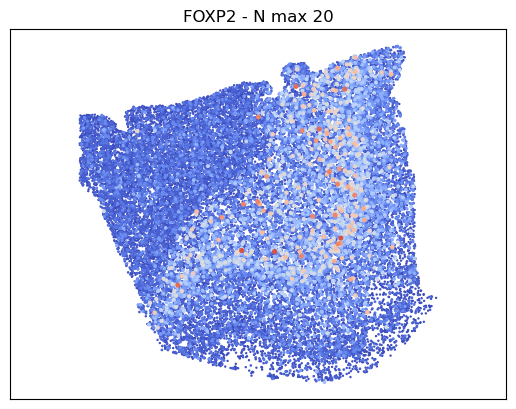

<Figure size 1500x1500 with 0 Axes>

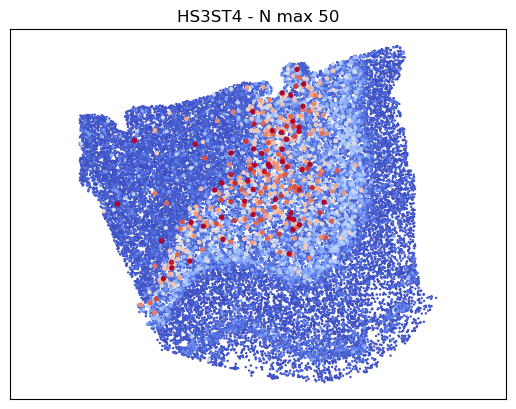

<Figure size 1500x1500 with 0 Axes>

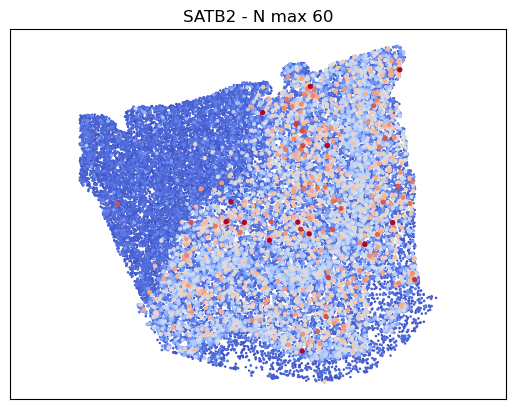

In [14]:
plot_gene_scdata(C4,gene='CUX2',nmax=30,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_CUX2.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='RORB',nmax=55,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_RORB.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='PFKP',nmax=200,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_PFKP.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='AHNAK2',nmax=80,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_AHNAK2.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='HTR2C',nmax=25,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_HTR2C.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='C1QL3',nmax=80,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_C1QL3.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='FOXP2',nmax=20,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_FOXP2.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='HS3ST4',nmax=50,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_HS3ST4.png', dpi=300, bbox_inches='tight')
plot_gene_scdata(C4,gene='SATB2',nmax=60,sz_min=0.5,sz_max=8,transpose=-1,flipx=1,flipy=1,tag='X_spatial');
plt.savefig('Figures/SF2C_SATB2.png', dpi=300, bbox_inches='tight')

In [15]:
###PLOT CLUSTER NAME
# Function to plot cell-types across single cells in X_spatial

def plot_cluster_name_scdata(scdata,cmap,clusters=['Neuron','Astro'],transpose=1,flipx=1,flipy=1,sbig=30,small=5):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(10, 10), facecolor="white")

    from matplotlib import pylab as plt
    x,y = (scdata.obsm['X_spatial']*[-flipx,-flipy])[:,::-transpose].T
    
    plt.scatter(x, y, c='gray', s=small, marker='.')
    i=0
    for cluster in clusters:
        cluster_ = str(cluster)
        inds = scdata.obs["cluster_names"] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[int(i) % len(cmap)]
        i=i+1
        plt.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_, linewidth=0.5, edgecolors='black')
    
    plt.grid(False)
    plt.axis("off")
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    return fig

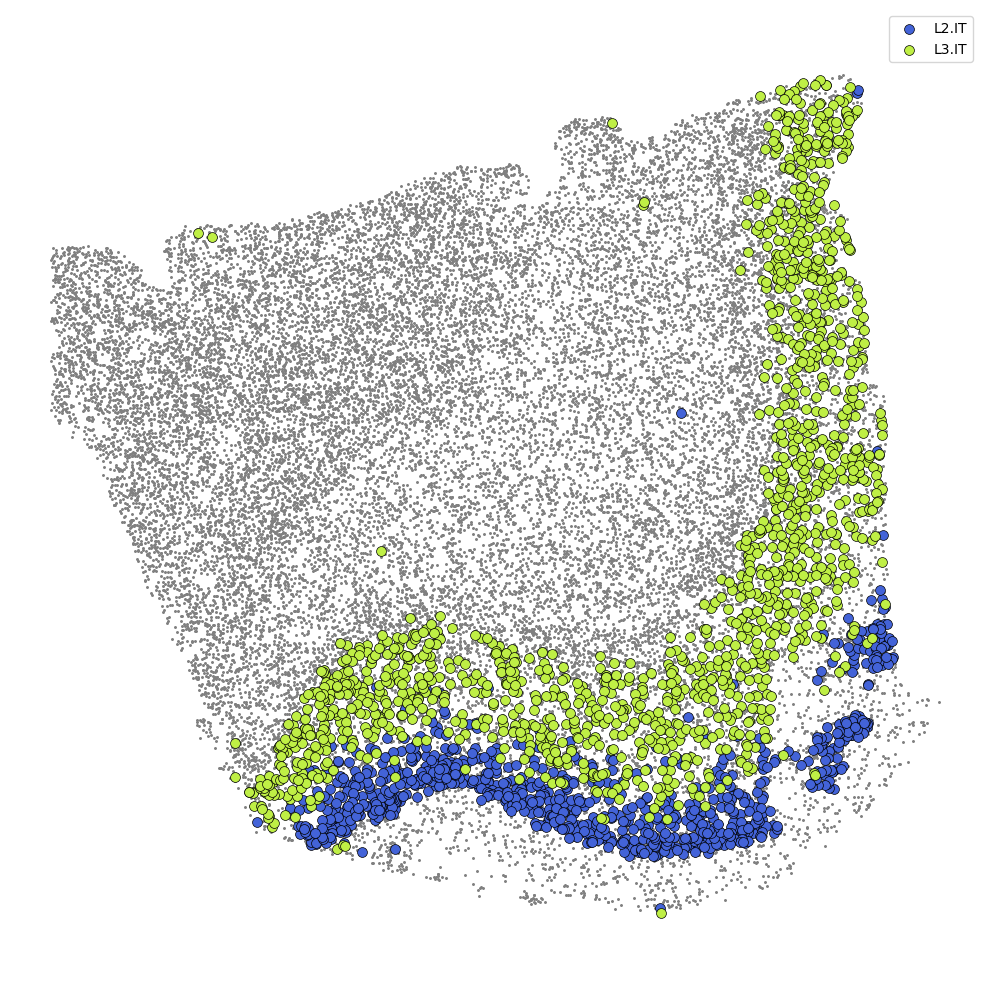

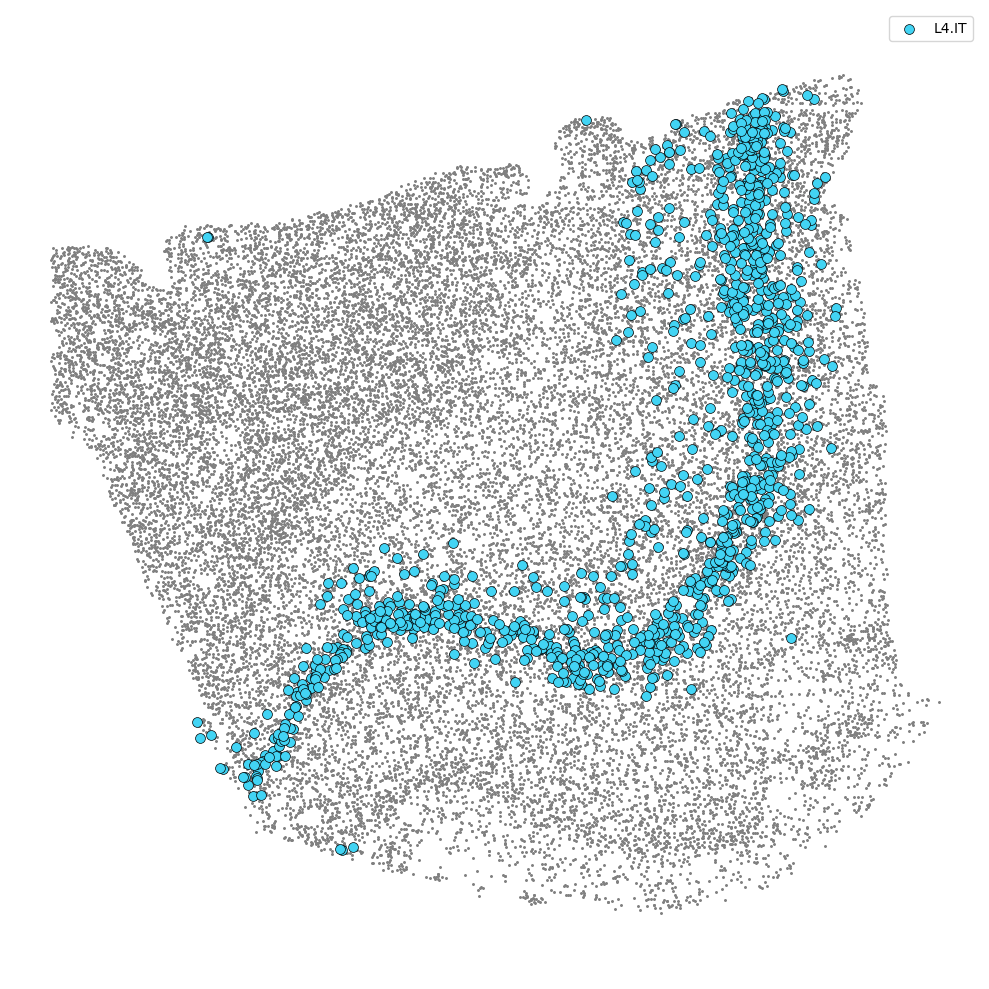

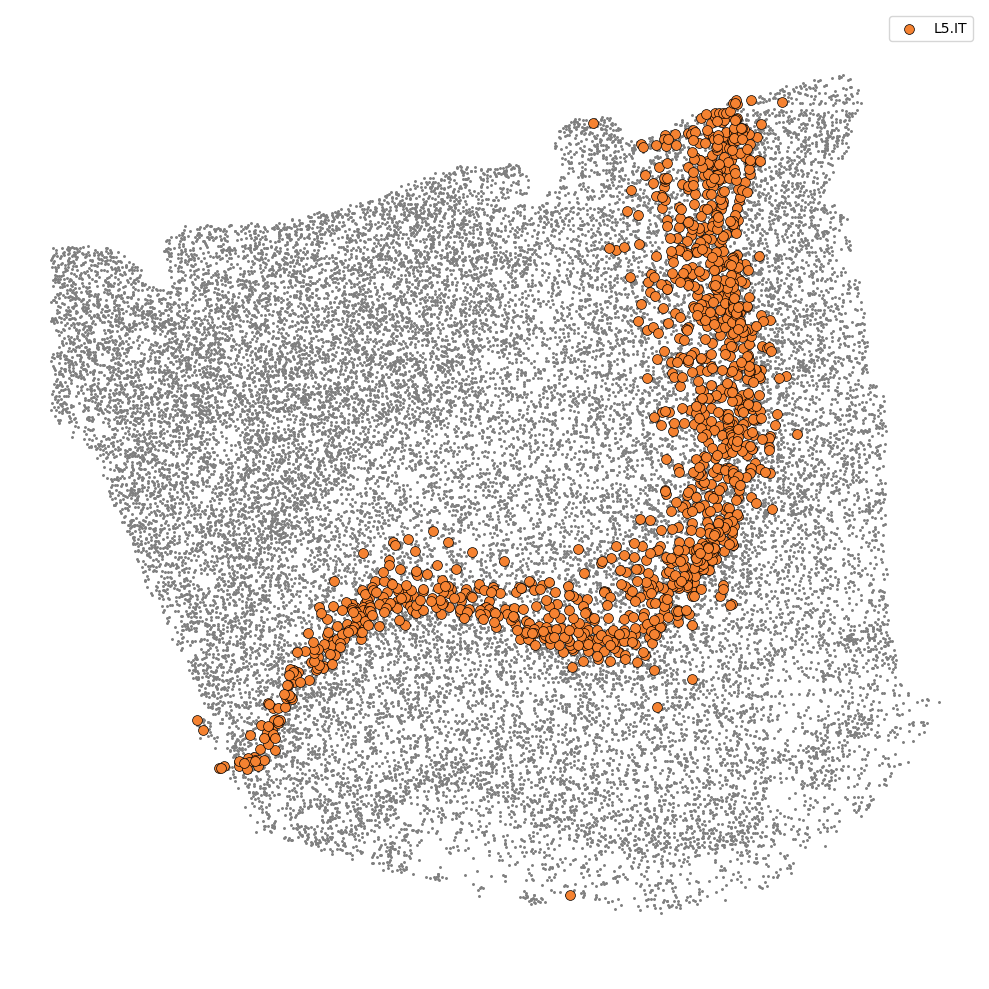

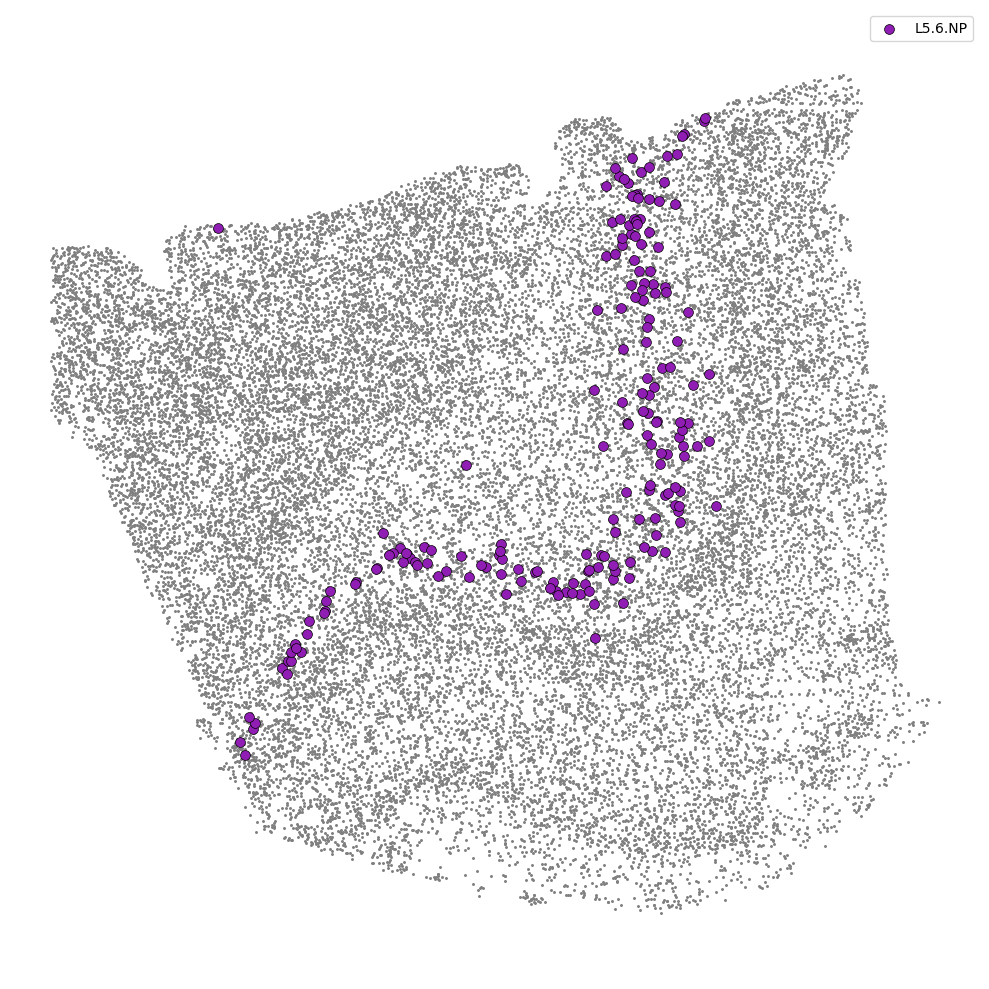

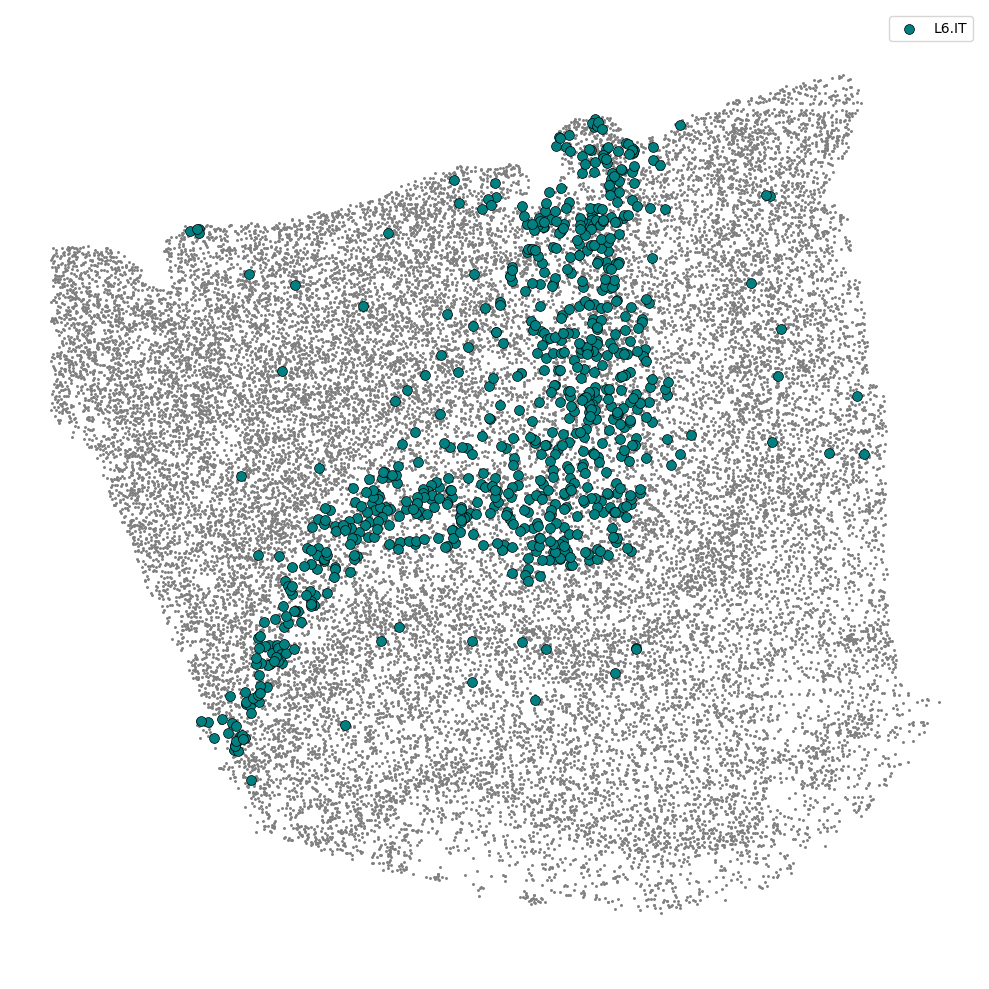

In [16]:
cmap = [
    '#4363d8', '#bfef45', #L2, L3, 
]
plot_cluster_name_scdata(C4,cmap,clusters=['L2.IT','L3.IT'],transpose=-1,flipx=1,flipy=1,sbig=200,small=5);
plt.savefig('Figures/SF2C_L2-3.png', dpi=300, bbox_inches='tight')

cmap = [
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
]
plot_cluster_name_scdata(C4,cmap,clusters=['L4.IT'],transpose=-1,flipx=1,flipy=1,sbig=200,small=5);
plt.savefig('Figures/SF2C_L4.png', dpi=300, bbox_inches='tight')

cmap = [
    '#f58231', #L5
]
plot_cluster_name_scdata(C4,cmap,clusters=['L5.IT'],transpose=-1,flipx=1,flipy=1,sbig=200,small=5);
plt.savefig('Figures/SF2C_L5.png', dpi=300, bbox_inches='tight')

cmap = [
    '#911eb4' #L56NP, L5ET, L5
]
plot_cluster_name_scdata(C4,cmap,clusters=['L5.6.NP'],transpose=-1,flipx=1,flipy=1,sbig=200,small=5);
plt.savefig('Figures/SF2C_L5NP.png', dpi=300, bbox_inches='tight')

cmap = [
   '#008080' #L6,
]
plot_cluster_name_scdata(C4,cmap,clusters=['L6.IT'],transpose=-1,flipx=1,flipy=1,sbig=200,small=5);
plt.savefig('Figures/SF2C_L6.png', dpi=300, bbox_inches='tight')

In [17]:
#######################################
#### SUPPLEMENTARY FIGURE 3A: MM-188 Cell-type correlation MERFISH vs ABA PFC
#######################################

In [18]:
s_adata=sc.read_h5ad('../W_Data_Short/adata_short.h5ad')

In [19]:
common_var = np.intersect1d(list(merged_dt.gene),list(s_adata.var.index))
merged_dt_short=merged_dt[merged_dt.gene.isin(common_var)]
merged_dt_short

,gene,L2/3 IT,L4 IT,L5 IT,L5 ET,L5/6 NP,L6 IT,L6 IT Car3,L6 CT,L6b,...,Sst,Sst Chodl,Pvalb,Chandelier,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
1024,CYP4B1,0.000892,0.000516,0.001153,0.004783,0.000241,0.000555,0.001987,0.001485,0.000619,...,0.000290,0.000000,0.000724,0.000939,0.000679,0.000000,0.000326,0.020006,0.000000,0.000000
1057,ELAVL4,0.660730,0.974437,1.294473,1.205697,1.296520,0.697551,0.246427,0.800074,0.775958,...,0.488314,0.509382,0.784380,0.532718,0.042798,0.426349,0.053215,0.063354,0.072915,0.262093
1565,COL11A1,0.515388,0.720359,0.998485,0.175765,1.201316,0.057662,0.034635,0.727992,0.458455,...,0.135520,0.239113,0.031243,1.036091,0.360538,1.609134,0.058088,0.088717,0.094394,0.051516
1580,NTNG1,0.903355,0.803937,0.504009,1.538542,0.017442,0.034651,1.064627,0.021907,0.023299,...,0.110115,0.222864,0.030862,0.584068,0.239817,1.646516,0.057590,0.420548,0.060832,0.068594
2176,LMNA,0.079378,0.085539,0.127490,0.201943,0.162831,0.066558,0.049327,0.157429,0.135760,...,0.123222,0.156241,0.237269,0.219472,0.176801,0.194085,0.160655,0.234416,0.650138,0.016170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34918,ISX,0.000026,0.000679,0.000361,0.000000,0.000351,0.000000,0.000437,0.000000,0.000340,...,0.000129,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
35627,EBP,0.060289,0.090049,0.090278,0.084300,0.104698,0.090669,0.093681,0.099048,0.114766,...,0.110434,0.107139,0.100610,0.096491,0.042659,0.055757,0.028293,0.040138,0.040150,0.033733
36009,IL1RAPL2,0.117268,1.986208,2.302490,0.040673,0.131802,1.325608,0.079213,0.042502,0.033344,...,0.055714,3.033418,0.112511,0.510972,0.063585,0.063378,0.069674,0.034094,0.065737,0.075401
36051,DCX,0.325345,0.228003,0.135627,0.680564,0.481565,0.351101,0.365354,0.208475,0.431165,...,0.562594,0.718894,0.723205,0.698659,0.020762,0.229526,0.015878,0.012446,0.022336,0.018596


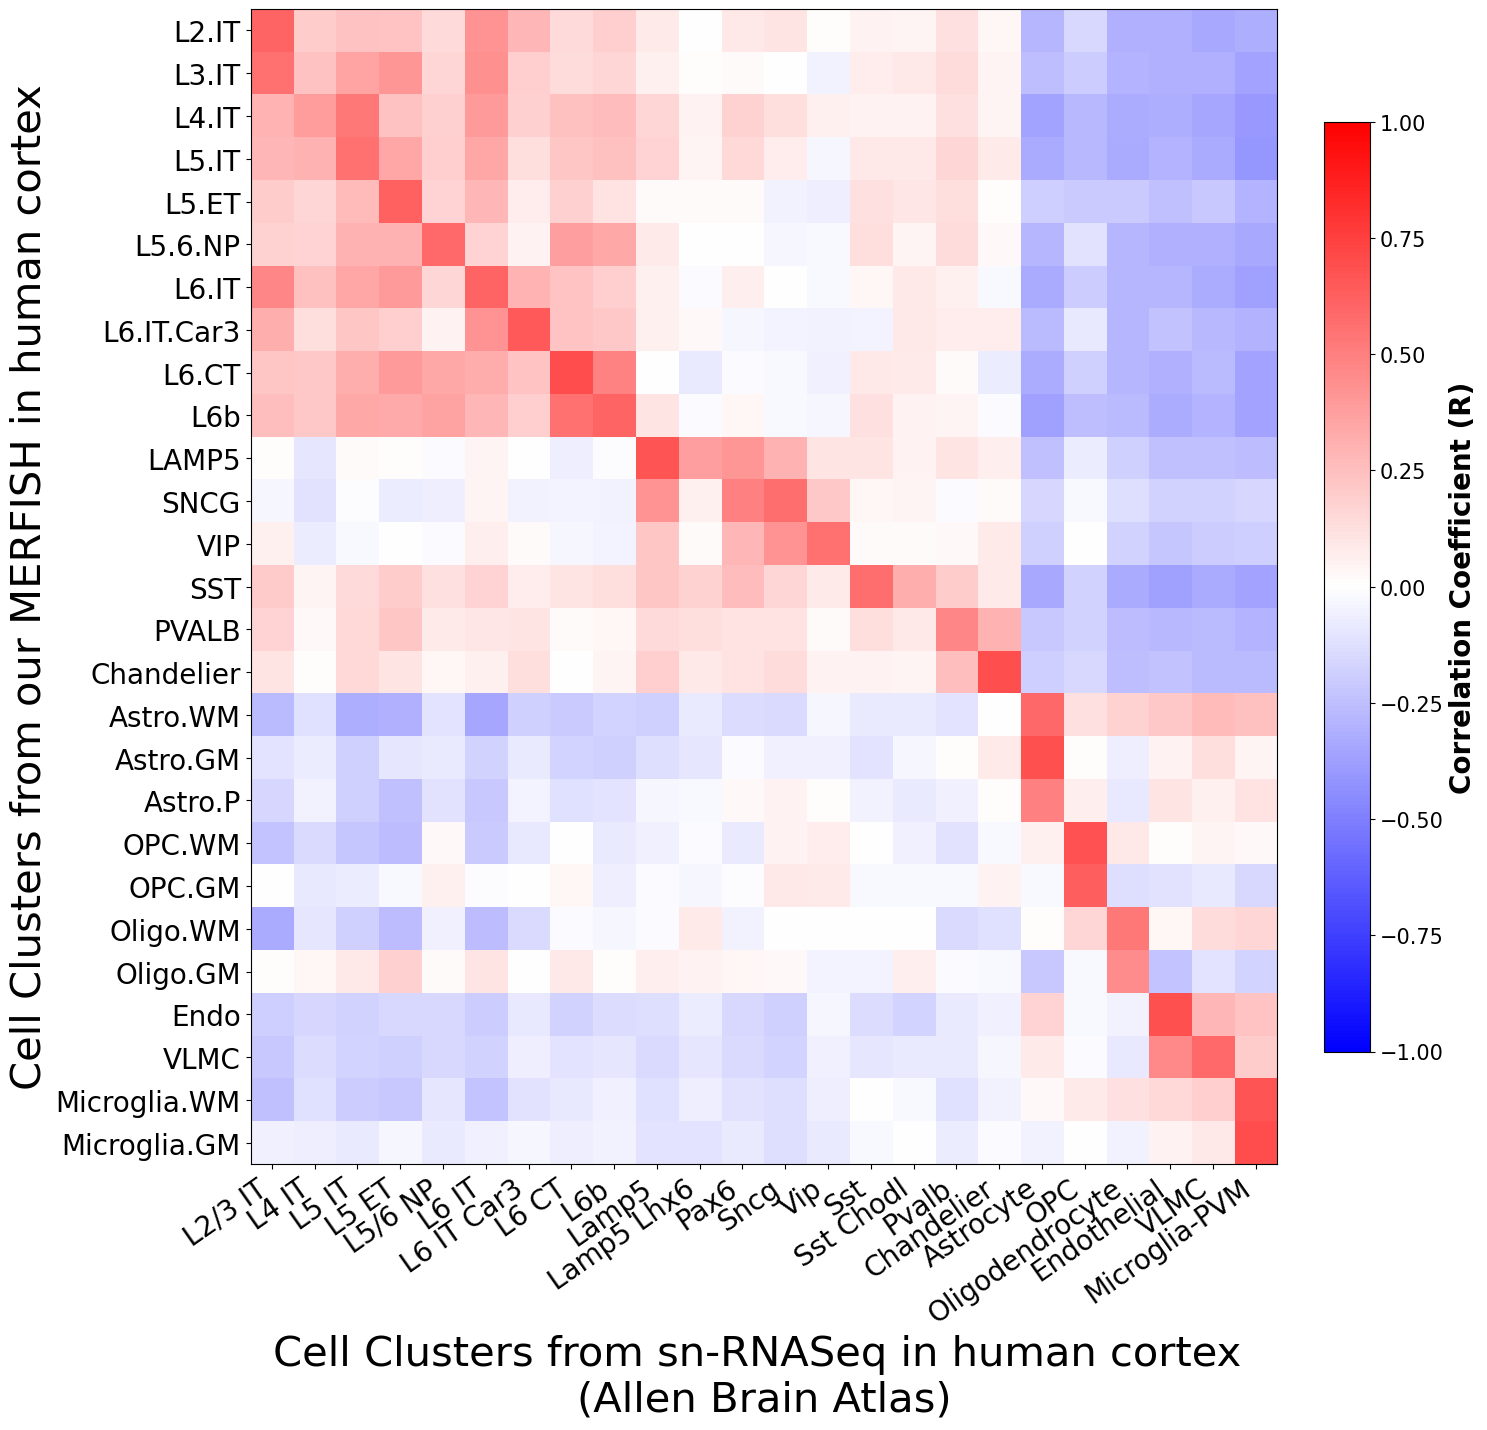

In [20]:
cluster_order = ["L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT','L6.IT.Car3', "L6.CT",'L6b',"LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "Astro.WM", 'Astro.GM','Astro.P', 'OPC.WM','OPC.GM',  'Oligo.WM', 'Oligo.GM','Endo', 'VLMC','Microglia.WM','Microglia.GM']
s_adata_s = s_adata[:,merged_dt_short["gene"]]

X_MERFISH_zscored = zscore(s_adata_s.X,axis=0)
clusters = s_adata_s.obs['cluster_names']
X_MERFISH_zscored_per_cluster = np.array([np.mean(X_MERFISH_zscored[cl==clusters],axis=0) for cl in cluster_order])

X_seq = np.array(merged_dt_short.iloc[:,1:]).T
X_seq[np.isnan(X_seq)]=0
X_seq_zscored = zscore(X_seq,axis=0)
X_seq_zscored[np.isnan(X_seq_zscored)]=0

Mcor = [[np.corrcoef(clMER,clSEQ)[0,1] for clSEQ in X_seq_zscored] for clMER in X_MERFISH_zscored_per_cluster]
xnames= list(merged_dt_short.keys())[1:]
dic_rename = dict(zip(s_adata_s.obs['leiden'],s_adata.obs['cluster_names']))

plt.style.use('default')
plt.figure(figsize=(30,15))
im = plt.imshow(Mcor,cmap='bwr', vmin=-1, vmax=1)
cbar = plt.colorbar(im, fraction=0.02, pad=0.02)
cbar.set_label('Correlation Coefficient (R)', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=15)
plt.xticks(np.arange(len(xnames)),xnames,rotation=35,ha='right',size=20);
plt.yticks(np.arange(len(cluster_order)),cluster_order,size=20)
plt.ylabel('Cell Clusters from our MERFISH in human cortex', size=30)
plt.xlabel('Cell Clusters from sn-RNASeq in human cortex \n(Allen Brain Atlas)', size=30)
plt.savefig('Figures/SF3A.png', dpi=300, bbox_inches='tight')

In [21]:
Mcor = np.array(Mcor)

max_r = Mcor.max(axis=1)
max_idx = Mcor.argmax(axis=1)
max_allen_clusters = [xnames[i] for i in max_idx]

results_df = pd.DataFrame({
    'MERFISH_cluster': cluster_order,
    'Max_correlation': max_r,
    'Best_matching_Allen_cluster': max_allen_clusters
})

mean_corr = np.mean(max_r)
std_corr = np.std(max_r)

t_stat, p_val = ttest_1samp(max_r.flatten(), 0)

print("===== Summary =====")
print(f"Mean correlation (all pairs): {mean_corr:.3f} ± {std_corr:.3f}")
print(f"T-test p-value (r > 0): {p_val:.5f}")
print()
print("===== Per-MERFISH Cluster Max Correlation =====")
print(results_df)


===== Summary =====
Mean correlation (all pairs): 0.600 ± 0.069
T-test p-value (r > 0): 0.00000

===== Per-MERFISH Cluster Max Correlation =====
   MERFISH_cluster  Max_correlation Best_matching_Allen_cluster
0            L2.IT         0.606043                     L2/3 IT
1            L3.IT         0.556877                     L2/3 IT
2            L4.IT         0.524024                       L5 IT
3            L5.IT         0.560037                       L5 IT
4            L5.ET         0.610655                       L5 ET
5          L5.6.NP         0.585438                     L5/6 NP
6            L6.IT         0.607033                       L6 IT
7       L6.IT.Car3         0.643050                  L6 IT Car3
8            L6.CT         0.696608                       L6 CT
9              L6b         0.601618                         L6b
10           LAMP5         0.665250                       Lamp5
11            SNCG         0.568921                        Sncg
12             VIP     

In [22]:
#######################################
#### SUPPLEMENTARY FIGURE 3B: MM-188 Cell-type correlation MERFISH vs MM-1182 Cell-type correlation MERFISH
#######################################

In [23]:
M_adata=sc.read_h5ad('../adata_0803_0908_f_AGG_orig.h5ad')

In [24]:
clusters = M_adata.obs['cluster_names']
clusters

Conv_zscan__043_4300113-4-0-0         L5.ET
Conv_zscan__017_1700121-4-0-0         L5.IT
Conv_zscan__035_3500197-4-0-0         L3.IT
Conv_zscan__201_20100036-4-0-0        L5.IT
Conv_zscan__016_1600014-4-0-0         L5.ET
                                    ...    
Conv_zscan__297_29700051-1-4-1    Microglia
Conv_zscan__016_27000016-1-4-1    Microglia
Conv_zscan__109_10900004-1-4-1    Microglia
Conv_zscan__010_1000153-1-4-1     Microglia
Conv_zscan__060_6100002-1-4-1      Oligo.WM
Name: cluster_names, Length: 185721, dtype: category
Categories (26, object): ['Astro.GM', 'Astro.P', 'Astro.WM', 'Chandelier', ..., 'SNCG', 'SST', 'VIP', 'VLMC']

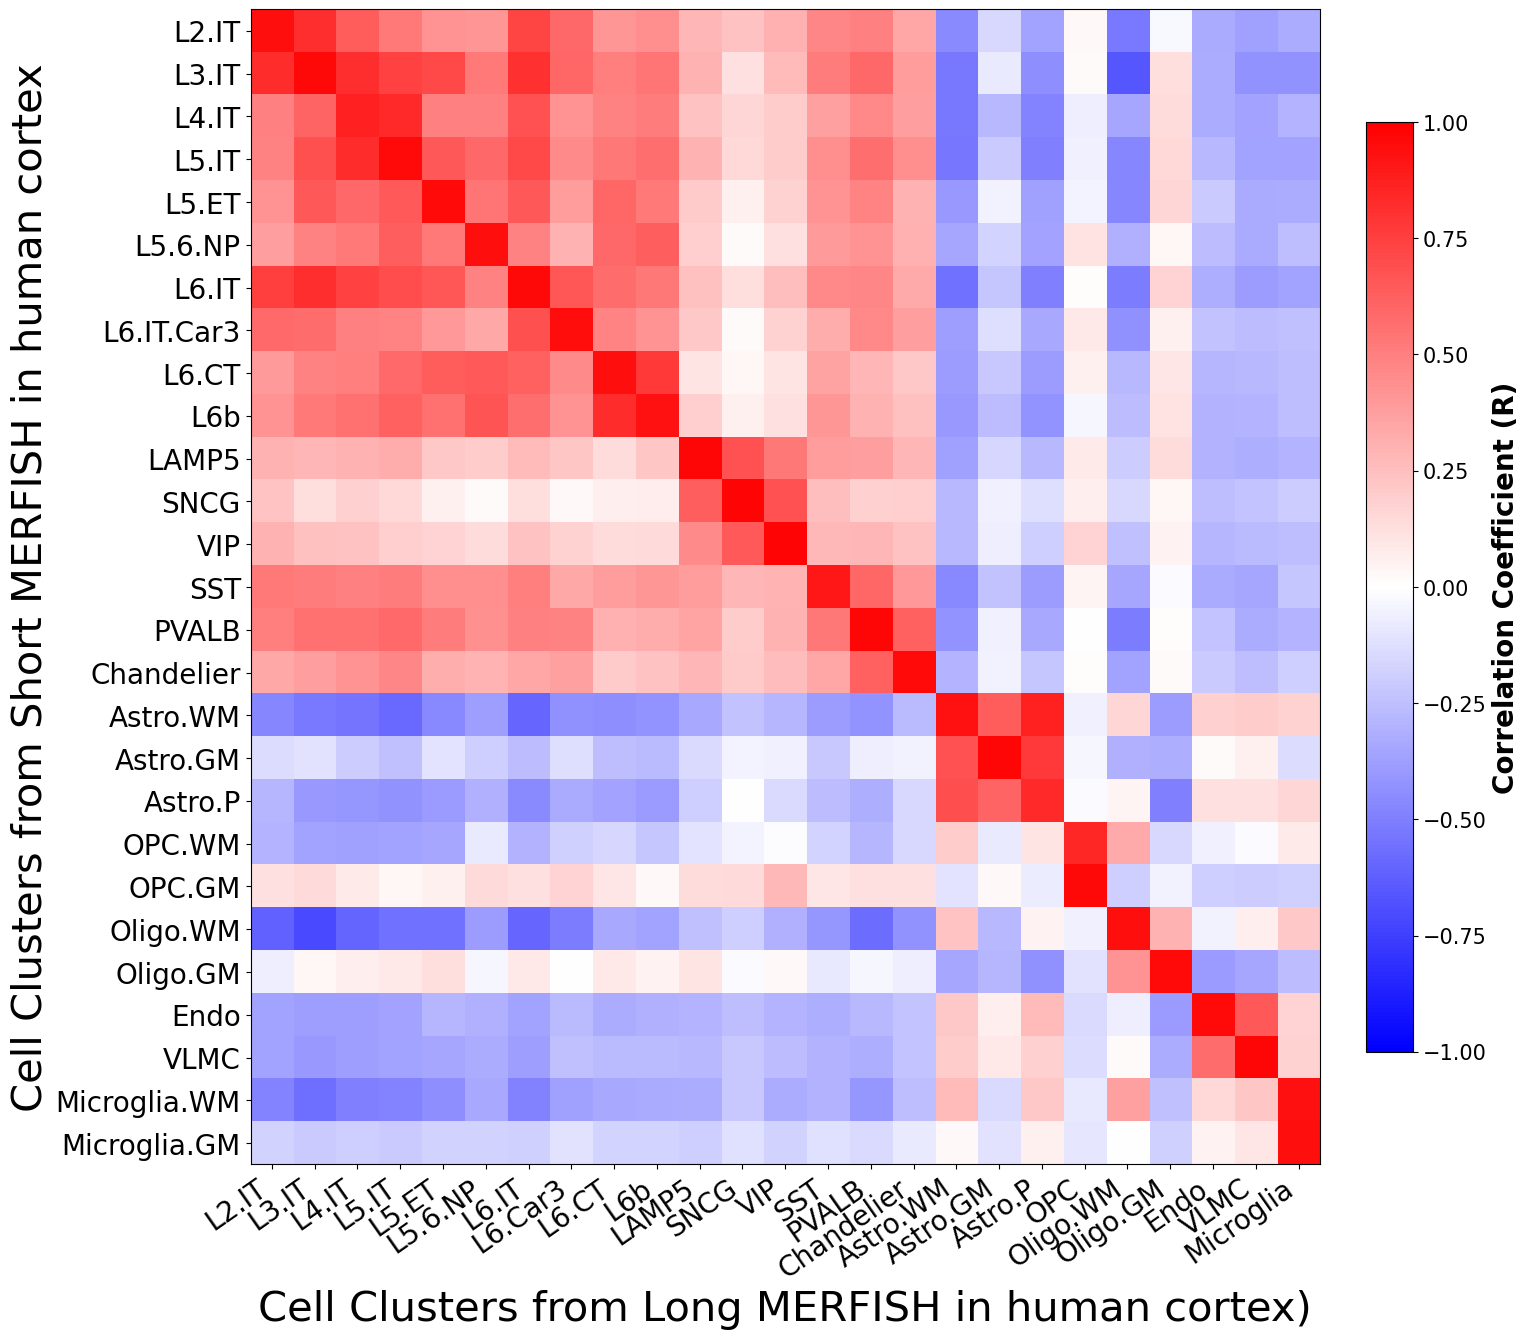

In [25]:
cluster_order_s = ["L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT','L6.IT.Car3', "L6.CT",'L6b',"LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "Astro.WM", 'Astro.GM','Astro.P', 'OPC.WM','OPC.GM',  'Oligo.WM', 'Oligo.GM','Endo', 'VLMC','Microglia.WM','Microglia.GM']
cluster_order_l = ["L2.IT", "L3.IT","L4.IT",'L5.IT', 'L5.ET', "L5.6.NP",'L6.IT','L6.Car3', "L6.CT",'L6b',"LAMP5", "SNCG",'VIP', "SST", "PVALB","Chandelier", "Astro.WM", 'Astro.GM','Astro.P', 'OPC',  'Oligo.WM', 'Oligo.GM','Endo', 'VLMC','Microglia']

M_adata_s = M_adata[:,s_adata.var_names]

L_X_MERFISH_zscored = zscore(M_adata_s.X,axis=0)
clusters = M_adata_s.obs['cluster_names']
L_X_MERFISH_zscored_per_cluster = np.array([np.mean(L_X_MERFISH_zscored[cl==clusters],axis=0) for cl in cluster_order_l])

S_X_MERFISH_zscored = zscore(s_adata.X,axis=0)
clusters = s_adata.obs['cluster_names']
S_X_MERFISH_zscored_per_cluster = np.array([np.mean(S_X_MERFISH_zscored[cl==clusters],axis=0) for cl in cluster_order_s])


Mcor = [[np.corrcoef(clSMER,clLMER)[0,1] for clLMER in L_X_MERFISH_zscored_per_cluster] for clSMER in S_X_MERFISH_zscored_per_cluster]

plt.style.use('default')
plt.figure(figsize=(30,15))
im = plt.imshow(Mcor,cmap='bwr', vmin=-1, vmax=1)
cbar = plt.colorbar(im, fraction=0.02, pad=0.02)
cbar.set_label('Correlation Coefficient (R)', fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=15)
plt.xticks(np.arange(len(cluster_order_l)),cluster_order_l,rotation=35,ha='right',size=20);
plt.yticks(np.arange(len(cluster_order_s)),cluster_order_s,size=20)
plt.ylabel('Cell Clusters from Short MERFISH in human cortex', size=30)
plt.xlabel('Cell Clusters from Long MERFISH in human cortex)', size=30)
plt.savefig('Figures/SF3B.png', dpi=300, bbox_inches='tight')

In [26]:
Mcor = np.array(Mcor)

max_r = Mcor.max(axis=1)
max_idx = Mcor.argmax(axis=1)
max_allen_clusters = [cluster_order_l[i] for i in max_idx]

results_df = pd.DataFrame({
    'MERFISH_cluster': cluster_order,
    'Max_correlation': max_r,
    'Best_matching_Allen_cluster': max_allen_clusters
})

mean_corr = np.mean(max_r)
std_corr = np.std(max_r)

t_stat, p_val = ttest_1samp(max_r.flatten(), 0)

print("===== Summary =====")
print(f"Mean correlation (all pairs): {mean_corr:.3f} ± {std_corr:.3f}")
print(f"T-test p-value (r > 0): {p_val:.5f}")
print()
print("===== Per-MERFISH Cluster Max Correlation =====")
print(results_df)


===== Summary =====
Mean correlation (all pairs): 0.941 ± 0.038
T-test p-value (r > 0): 0.00000

===== Per-MERFISH Cluster Max Correlation =====
   MERFISH_cluster  Max_correlation Best_matching_Allen_cluster
0            L2.IT         0.944582                       L2.IT
1            L3.IT         0.966767                       L3.IT
2            L4.IT         0.861274                       L4.IT
3            L5.IT         0.953328                       L5.IT
4            L5.ET         0.959247                       L5.ET
5          L5.6.NP         0.937774                     L5.6.NP
6            L6.IT         0.961508                       L6.IT
7       L6.IT.Car3         0.952609                     L6.Car3
8            L6.CT         0.943273                       L6.CT
9              L6b         0.928221                         L6b
10           LAMP5         0.968978                       LAMP5
11            SNCG         0.979375                        SNCG
12             VIP     